# Velocity and Efficiency Analysis using TruckScenes
This report presents the velocity and efficiency analysis conducted using the TruckScenes dataset.

The analysis focuses on how RADAR and LiDAR provide vehicle-motion information and sensor information for target-motion analysis across comparable vehicle-speed ranges.

The main research question is:

> How do RADAR, LiDAR and Camera compare in terms of velocity-related information and sensor information acquisition across comparable vehicle-speed ranges in TruckScenes?

## 1. Research Scope

This work focuses on two main aspects of sensor performance:

- **Velocity**
- **Efficiency**

### Velocity

Velocity is treated as a measurable continuous vehicle-motion metric.

Annotation-derived velocity is used as the common/reference vehicle-motion metric for later sensor comparison.

In this analysis:

- **Annotation-derived velocity** provides the common/reference vehicle-motion metric.
- **RADAR** provides direct velocity-related information.
- **LiDAR** provides spatial and temporal target information, but does not contain a direct velocity field.
- **Camera** provides visual and temporal target information, but does not contain a direct velocity field. Camera-based velocity estimation, such as optical-flow-based estimation, is not used in this analysis.

Vehicle speed ranges are used for analysis grouping and stratification.

### Efficiency

Efficiency is defined as sensor information acquisition performance and availability for target-motion analysis.

The analysis therefore compares measurable information-availability indicators for RADAR, LiDAR, and Camera, using sensor-appropriate metrics rather than treating their raw information quantities as directly equivalent.

A composite efficiency score is not used in this analysis.

## 2. Dataset and Analysis Setup

This analysis uses the TruckScenes `v1.2-mini` dataset during development. Dataset paths and the active metadata version are managed through the shared project configuration so that the same analysis workflow can later be applied to the complete TruckScenes dataset without changing the report logic.

TruckScenes provides RADAR, LiDAR, and camera observations together with object annotations, sensor calibration, ego-motion information, and timestamps. The velocity analysis in this report focuses primarily on RADAR and LiDAR. Camera data is not used to derive vehicle velocity, but is retained for later sensor-information and visibility-related analysis.


In [30]:
import pandas as pd
from src.config import VERSION, METADATA_ROOT, TIMESTAMP_UNITS_PER_SECOND
from src.data_io import load_json
import matplotlib.pyplot as plt
import numpy as np

from src.annotation_velocity import build_annotation_trajectory_df, build_annotation_pairs, add_time_differences, add_position_changes, add_reference_velocity
from src.sensor_observation import build_sensor_data_df
from src.radar_velocity import build_target_radar_points_df, build_target_radar_velocity_df, build_radar_radial_df, build_radar_velocity_df

In [15]:
sensor_df = pd.DataFrame(load_json(METADATA_ROOT / "sensor.json"))
sensor_summary = sensor_df.groupby("modality", as_index=False).agg(Number_of_Channels=("channel", "nunique"), Channels=("channel", lambda x: ", ".join(sorted(x))))

print(f"TruckScenes dataset: {VERSION}")
display(sensor_summary)

TruckScenes dataset: v1.2-mini


,modality,Number_of_Channels,Channels
0,camera,4,"CAMERA_LEFT_BACK, CAMERA_LEFT_FRONT, CAMERA_RI..."
1,imu,2,"XSENSE_CABIN, XSENSE_CHASSIS"
2,lidar,6,"LIDAR_LEFT, LIDAR_REAR, LIDAR_RIGHT, LIDAR_TOP..."
3,radar,6,"RADAR_LEFT_BACK, RADAR_LEFT_FRONT, RADAR_LEFT_..."


### 2.1 Relevant Metadata Structure

Only the metadata required by the later analysis is retained here.

| Metadata                          | Role in the analysis                                                                                           |
| --------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| `sample.json`                     | Defines key samples, scene membership, and sample timestamps.                                                  |
| `sample_data.json`                | Links individual sensor observations to samples and provides sensor-observation timestamps and file locations. |
| `sensor.json`                     | Identifies sensor modality and channel.                                                                        |
| `calibrated_sensor.json`          | Provides the position and orientation of each calibrated sensor.                                               |
| `sample_annotation.json`          | Provides annotated object position and temporal links between annotations.                                     |
| `instance.json` / `category.json` | Links annotations belonging to the same physical object and identifies object category.                        |
| `ego_pose.json`                   | Provides the ego-vehicle pose required for coordinate transformations.                                         |
| `ego_motion_chassis.json`         | Provides ego-vehicle motion information where required by later sensor analysis.                               |

TruckScenes metadata timestamps used in this analysis are stored in microseconds. Therefore,

$$
t_{\mathrm{s}}=\frac{t_{\mu s}}{1{,}000{,}000}.
$$

`sample.timestamp` represents the timestamp of the annotation/key-sample reference, while `sample_data.timestamp` represents the timestamp of an individual sensor observation. These two timestamps are therefore kept distinct in the later alignment analysis.


### 2.2 Samples, Sweeps, and Vehicle Annotations

TruckScenes contains both key-sample observations and intermediate sweep observations. A `sample` represents a key point in the annotated scene timeline, while `sample_data` contains the individual sensor observations linked to that sample. Sensor files stored under `samples/` correspond to key observations, while `sweeps/` provides additional intermediate observations between key samples.

This distinction is important because annotation-derived reference velocity is based on the key-sample annotation timeline, whereas sensor-information acquisition may use the denser sequence of available sensor observations.

Object annotations are linked through

`sample_annotation.sample_token` → `sample.token`

and

`sample_annotation.instance_token` → `instance.token` → `category`.

The `prev` and `next` annotation links allow consecutive observations of the same physical object to be followed through time. For the vehicle analysis, categories beginning with `vehicle.*` are treated as target vehicles, with `vehicle.ego_trailer` excluded because it belongs to the recording vehicle rather than an independent target vehicle.


## 3. Reference Vehicle Motion and Efficiency Analysis Inputs

This section establishes the common analysis inputs used by the later sensor-specific and cross-sensor analyses.

First, vehicle motion is derived from consecutive TruckScenes object annotations. **Annotation-derived velocity is used as the common/reference vehicle-motion metric throughout the later analysis.** It is independent of RADAR, LiDAR, Camera, and ego-motion measurements.

Second, efficiency-related information is prepared for the three sensor modalities. Target-level RADAR and LiDAR point counts are retained from the annotation metadata, while sensor-observation metadata is used to identify the available RADAR, LiDAR, and Camera observations and their timestamps.

This section prepares the common reference and analysis inputs only. It does not compare sensor performance.


### 3.1 Annotation-derived Reference Velocity

A common vehicle-motion reference is required before the sensor-specific analyses are performed. In this report, vehicle motion is derived from consecutive TruckScenes object annotations rather than directly from RADAR, LiDAR, Camera, or ego-motion measurements.

**Annotation-derived velocity is the common/reference vehicle-motion metric used throughout the later analysis.** This section therefore establishes the reference motion only; it does not compare sensor performance.

Annotations belonging to the same physical object are linked through their `instance_token` and consecutive `next` relationships. Each annotation is associated with its corresponding key-sample timestamp and 3D position.

For two consecutive annotations,

$$
\Delta t=\frac{t_{end}-t_{start}}{1{,}000{,}000},
$$

where TruckScenes timestamps are stored in microseconds and \(\Delta t\) is expressed in seconds.

Position changes are calculated as

$$
\Delta x=x_{end}-x_{start},\qquad
\Delta y=y_{end}-y_{start},\qquad
\Delta z=z_{end}-z_{start}.
$$

The 2D and 3D displacements are

$$
d_{2D}=\sqrt{\Delta x^2+\Delta y^2},
$$

$$
d_{3D}=\sqrt{\Delta x^2+\Delta y^2+\Delta z^2}.
$$

The corresponding reference speeds are

$$
v_{2D}=\frac{d_{2D}}{\Delta t},\qquad
v_{3D}=\frac{d_{3D}}{\Delta t}.
$$

The 2D ground-plane speed is used as the primary vehicle-motion reference because road vehicles mainly move in the horizontal plane. The 3D speed is retained as a diagnostic measure for evaluating the influence of vertical annotation changes.


In [16]:
samples = load_json(METADATA_ROOT / "sample.json")
annotations = load_json(METADATA_ROOT / "sample_annotation.json")
instances = load_json(METADATA_ROOT / "instance.json")
categories = load_json(METADATA_ROOT / "category.json")

trajectory_df = build_annotation_trajectory_df(samples=samples, annotations=annotations, instances=instances, categories=categories)
annotation_pairs = build_annotation_pairs(trajectory_df)
annotation_pairs = add_time_differences(annotation_pairs)
annotation_pairs = add_position_changes(annotation_pairs)
velocity_df = add_reference_velocity(annotation_pairs)

vehicle_reference_df = velocity_df[
    velocity_df["category"].str.startswith("vehicle.")
    & (velocity_df["category"] != "vehicle.ego_trailer")
].copy()

vehicle_reference_df["speed_2d_kmh"] = vehicle_reference_df["speed_2d_mps"] * 3.6
vehicle_reference_df["speed_3d_kmh"] = vehicle_reference_df["speed_3d_mps"] * 3.6

In [17]:
reference_summary = pd.DataFrame({
    "Metric": [
        "Annotations",
        "Object instances",
        "Consecutive annotation pairs",
        "Median Δt (s)",
        "Maximum Δt (s)",
        "Non-positive Δt",
        "Vehicle reference intervals",
        "Vehicle instances",
        "Median 2D vehicle speed (m/s)",
        "Median 3D vehicle speed (m/s)"
    ],
    "Value": [
        len(trajectory_df),
        trajectory_df["instance_token"].nunique(),
        len(annotation_pairs),
        annotation_pairs["dt_s"].median(),
        annotation_pairs["dt_s"].max(),
        (annotation_pairs["dt_s"] <= 0).sum(),
        len(vehicle_reference_df),
        vehicle_reference_df["instance_token"].nunique(),
        vehicle_reference_df["speed_2d_mps"].median(),
        vehicle_reference_df["speed_3d_mps"].median()
    ]
})

display(reference_summary.round(3))

,Metric,Value
0,Annotations,25750.000
1,Object instances,1094.000
2,Consecutive annotation pairs,24656.000
3,Median Δt (s),0.500
4,Maximum Δt (s),12.000
5,Non-positive Δt,0.000
6,Vehicle reference intervals,15743.000
7,Vehicle instances,750.000
8,Median 2D vehicle speed (m/s),4.097
9,Median 3D vehicle speed (m/s),4.321


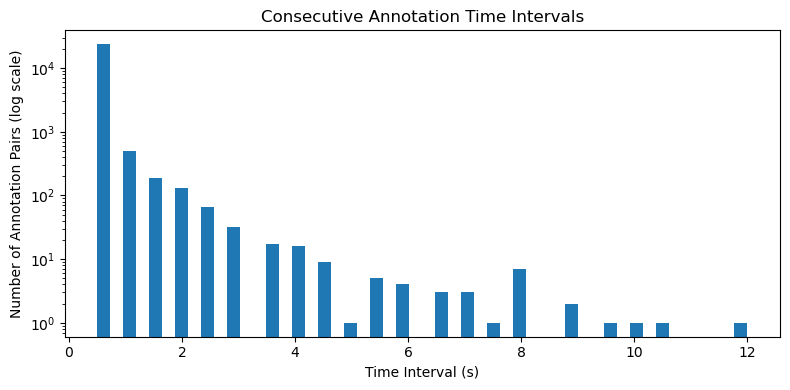

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(annotation_pairs["dt_s"], bins=50)
plt.yscale("log")
plt.xlabel("Time Interval (s)")
plt.ylabel("Number of Annotation Pairs (log scale)")
plt.title("Consecutive Annotation Time Intervals")
plt.tight_layout()
plt.show()

Most consecutive annotation pairs are separated by approximately 0.5 s, indicating that the reference velocity is generally calculated over a consistent keyframe interval. No non-positive time intervals were identified, while a small number of longer gaps are present, with the maximum interval reaching approximately 12 s. The derived velocity therefore represents the average target motion between consecutive annotations rather than an instantaneous velocity measurement.

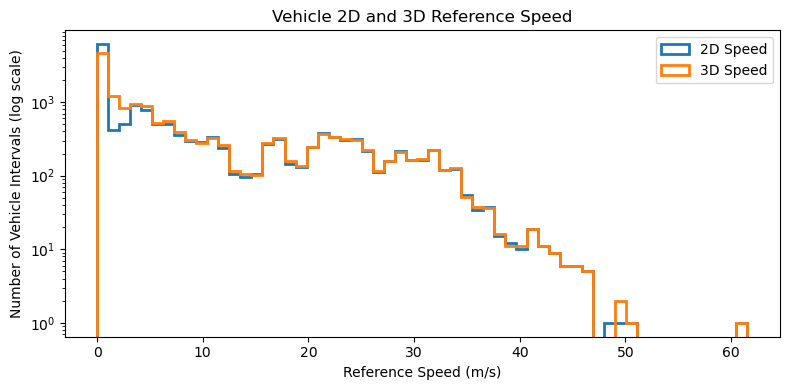

In [22]:
bins = np.linspace(0, vehicle_reference_df[["speed_2d_mps", "speed_3d_mps"]].to_numpy().max(), 60)

plt.figure(figsize=(8, 4))
plt.hist(vehicle_reference_df["speed_2d_mps"], bins=bins, histtype="step", linewidth=2, label="2D Speed")
plt.hist(vehicle_reference_df["speed_3d_mps"], bins=bins, histtype="step", linewidth=2, label="3D Speed")
plt.yscale("log")
plt.xlabel("Reference Speed (m/s)")
plt.ylabel("Number of Vehicle Intervals (log scale)")
plt.title("Vehicle 2D and 3D Reference Speed")
plt.legend()
plt.tight_layout()
plt.show()

The 2D and 3D reference-speed distributions show a similar overall pattern, with median speeds of approximately 4.10 m/s and 4.32 m/s, respectively. The relatively small difference indicates that horizontal motion accounts for most of the measured vehicle displacement. Therefore, 2D ground-plane speed is used as the primary reference vehicle-motion metric in the later analysis, while 3D speed is retained as a diagnostic measure for vertical annotation changes.


### 3.2 Efficiency-related Information Preparation

The later efficiency analysis evaluates the amount and availability of usable sensor information under comparable vehicle-motion conditions.

TruckScenes annotations provide target-associated `num_radar_pts` and `num_lidar_pts` fields. These are retained as sensor-specific measures of the amount of RADAR and LiDAR information associated with each annotated target vehicle.

Camera information is structured differently. There is no directly equivalent target-level camera point-count field in the annotation metadata. Camera efficiency is therefore prepared at the sensor-observation level using `sample_data.json`, including observation availability, channel, timestamp, and image filename. Image-derived measures such as brightness or visibility are calculated later in the Camera analysis.

RADAR and LiDAR point counts are not treated as directly equivalent quantities because the two sensors provide different types of information. The final efficiency analysis therefore considers information availability, amount, and type rather than comparing raw point counts alone.


In [24]:
category_lookup = {c["token"]: c["name"] for c in categories}
instance_category = {i["token"]: category_lookup[i["category_token"]] for i in instances}

vehicle_annotation_df = pd.DataFrame([
    {
        "annotation_token": a["token"],
        "instance_token": a["instance_token"],
        "sample_token": a["sample_token"],
        "category": instance_category[a["instance_token"]],
        "num_radar_pts": a["num_radar_pts"],
        "num_lidar_pts": a["num_lidar_pts"]
    }
    for a in annotations
    if instance_category[a["instance_token"]].startswith("vehicle.")
    and instance_category[a["instance_token"]] != "vehicle.ego_trailer"
])

In [28]:
sample_data = load_json(METADATA_ROOT / "sample_data.json")
calibrated_sensors = load_json(METADATA_ROOT / "calibrated_sensor.json")
sensors = load_json(METADATA_ROOT / "sensor.json")

calibrated_lookup = {c["token"]: c for c in calibrated_sensors}
sensor_lookup = {s["token"]: s for s in sensors}
modality_names = {"radar": "RADAR", "lidar": "LiDAR", "camera": "Camera"}

sensor_records = []

for sd in sample_data:
    calibrated = calibrated_lookup[sd["calibrated_sensor_token"]]
    sensor = sensor_lookup[calibrated["sensor_token"]]
    modality = modality_names.get(sensor["modality"].lower())

    if modality is None:
        continue

    sensor_records.append({
        "sample_data_token": sd["token"],
        "sample_token": sd["sample_token"],
        "modality": modality,
        "channel": sensor["channel"],
        "timestamp_us": sd["timestamp"],
        "timestamp_s": sd["timestamp"] / TIMESTAMP_UNITS_PER_SECOND,
        "filename": sd["filename"]
    })

sensor_observation_df = pd.DataFrame(sensor_records)

The annotation workflow provides a common vehicle-motion reference independent of the sensor measurements. The resulting 2D ground-plane speed is used as the primary reference metric, while the 3D speed is retained for diagnostic purposes. In parallel, target-level RADAR and LiDAR point counts and observation-level RADAR, LiDAR, and Camera metadata have been prepared for the later efficiency analysis. No sensor-performance comparison is performed at this stage.

## 4. RADAR Analysis

This section examines the velocity-related information and target-associated information provided by TruckScenes RADAR.

Two aspects are considered. First, the direct RADAR velocity-related measurements are analysed at return and target level. Second, RADAR information acquisition is evaluated using target availability, associated return count, and sensor support.

The annotation-derived 2D ground-plane speed established in Section 3 is used to define comparable reference-speed ranges. These ranges provide common vehicle-motion conditions for the analysis.

A secondary analysis evaluates whether the available RADAR velocity information can support a stable 2D target-velocity estimate. Cross-sensor comparison is performed later.

### 4.1 RADAR Velocity-related Information

All six TruckScenes RADAR channels contain the fields `x`, `y`, `z`, `vrel_x`, `vrel_y`, `vrel_z`, and `rcs`.

The fields `vrel_x`, `vrel_y`, and `vrel_z` provide direct point-level relative-velocity information. For each RADAR return, the relative-velocity magnitude is calculated as

```math
v_{\mathrm{rel}}=\sqrt{v_{\mathrm{rel},x}^{2}+v_{\mathrm{rel},y}^{2}+v_{\mathrm{rel},z}^{2}}.
```

The velocity components from different RADAR sensors are expressed in their individual sensor coordinate frames and are therefore not directly averaged across sensors. The relative-velocity magnitude is used as a common target-level summary of the direct RADAR velocity information.

This quantity is not equivalent to the annotation-derived absolute vehicle speed. The annotation-derived speed defines the common reference-motion condition, while vrel represents relative-motion information directly provided by RADAR.

In [31]:
sensor_data_df = build_sensor_data_df()
sample_data = load_json(METADATA_ROOT / "sample_data.json")
sample_data_lookup = {x["token"]: x for x in sample_data}

radar_observation_df = sensor_data_df[sensor_data_df["Modality"] == "RADAR"].copy()
radar_observation_df["Is Key Frame"] = radar_observation_df["Token"].map(lambda x: sample_data_lookup[x]["is_key_frame"])
keyframe_radar = radar_observation_df[radar_observation_df["Is Key Frame"]].copy()

target_radar_points_df = build_target_radar_points_df(keyframe_radar)
target_radar_df = build_target_radar_velocity_df(target_radar_points_df)

RADAR target association is performed using keyframe observations. Annotation boxes are transformed into each RADAR sensor frame and returns located inside the corresponding target boxes are retained.

The keyframe observations are closely aligned with the linked annotation samples, with a median absolute timestamp offset of approximately 5.44 ms and a maximum of approximately 55.84 ms. The association workflow was also validated against the annotation `num_radar_pts` metadata for a six-sensor keyframe sample, producing exact agreement for all 69 vehicle annotations.

### 4.2 Overall RADAR Velocity and Information Acquisition

In [32]:
radar_summary = pd.DataFrame({
    "Metric": ["RADAR observations", "Keyframe RADAR observations", "Target-associated RADAR returns", "Target observations", "Target vehicles", "Median returns per target", "Single-return observations"],
    "Value": [len(radar_observation_df), len(keyframe_radar), len(target_radar_points_df), len(target_radar_df), target_radar_df["instance_token"].nunique(), target_radar_df["radar_return_count"].median(), (target_radar_df["radar_return_count"] == 1).sum()]
})

display(radar_summary)

,Metric,Value
0,RADAR observations,23439.0
1,Keyframe RADAR observations,2400.0
2,Target-associated RADAR returns,52184.0
3,Target observations,9588.0
4,Target vehicles,639.0
5,Median returns per target,3.0
6,Single-return observations,2845.0


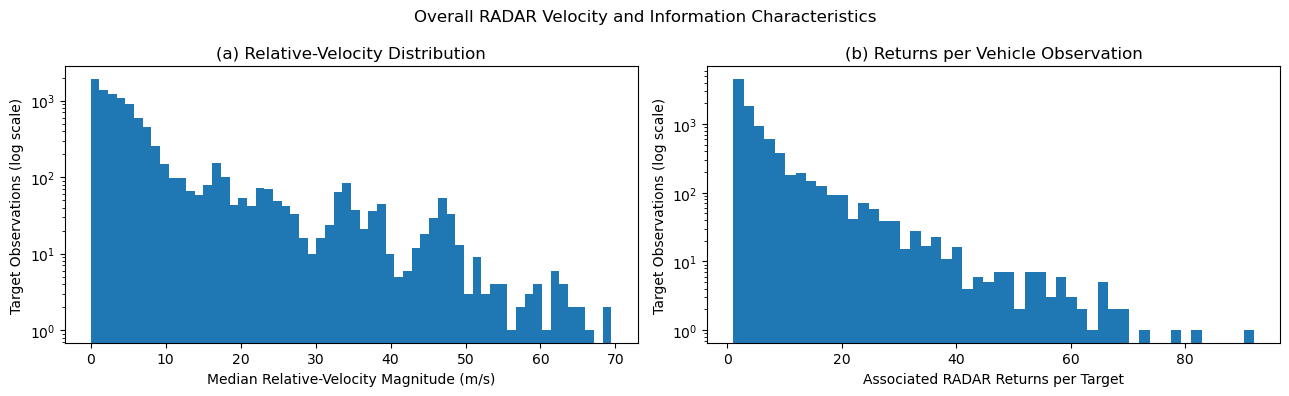

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(target_radar_df["median_vrel_magnitude"], bins=60)
axes[0].set_yscale("log")
axes[0].set_xlabel("Median Relative-Velocity Magnitude (m/s)")
axes[0].set_ylabel("Target Observations (log scale)")
axes[0].set_title("(a) Relative-Velocity Distribution")

axes[1].hist(target_radar_df["radar_return_count"], bins=50)
axes[1].set_yscale("log")
axes[1].set_xlabel("Associated RADAR Returns per Target")
axes[1].set_ylabel("Target Observations (log scale)")
axes[1].set_title("(b) Returns per Vehicle Observation")

fig.suptitle("Overall RADAR Velocity and Information Characteristics")
plt.tight_layout()
plt.show()

The two distributions describe complementary characteristics of target-level RADAR information. Relative-velocity measurements are strongly right-skewed, with most target observations containing relatively small velocity magnitudes and a smaller number extending to substantially larger values. Target-associated information amount is similarly uneven: most vehicle observations contain only a small number of RADAR returns, with a median of three returns per target. RADAR therefore provides direct relative-motion information, but the amount of information available for individual targets is generally sparse and variable.

### 4.3 Sensor-level RADAR Characteristics

In [35]:
radar_point_df = target_radar_points_df.copy()
radar_point_df["vrel_magnitude"] = np.sqrt(radar_point_df["vrel_x"]**2 + radar_point_df["vrel_y"]**2 + radar_point_df["vrel_z"]**2)

radar_sensor_target_df = radar_point_df.groupby(["sensor", "annotation_token"], as_index=False).agg(
    radar_return_count=("vrel_magnitude", "size"),
    median_vrel_magnitude=("vrel_magnitude", "median")
)

radar_sensors = sorted(radar_sensor_target_df["sensor"].unique())

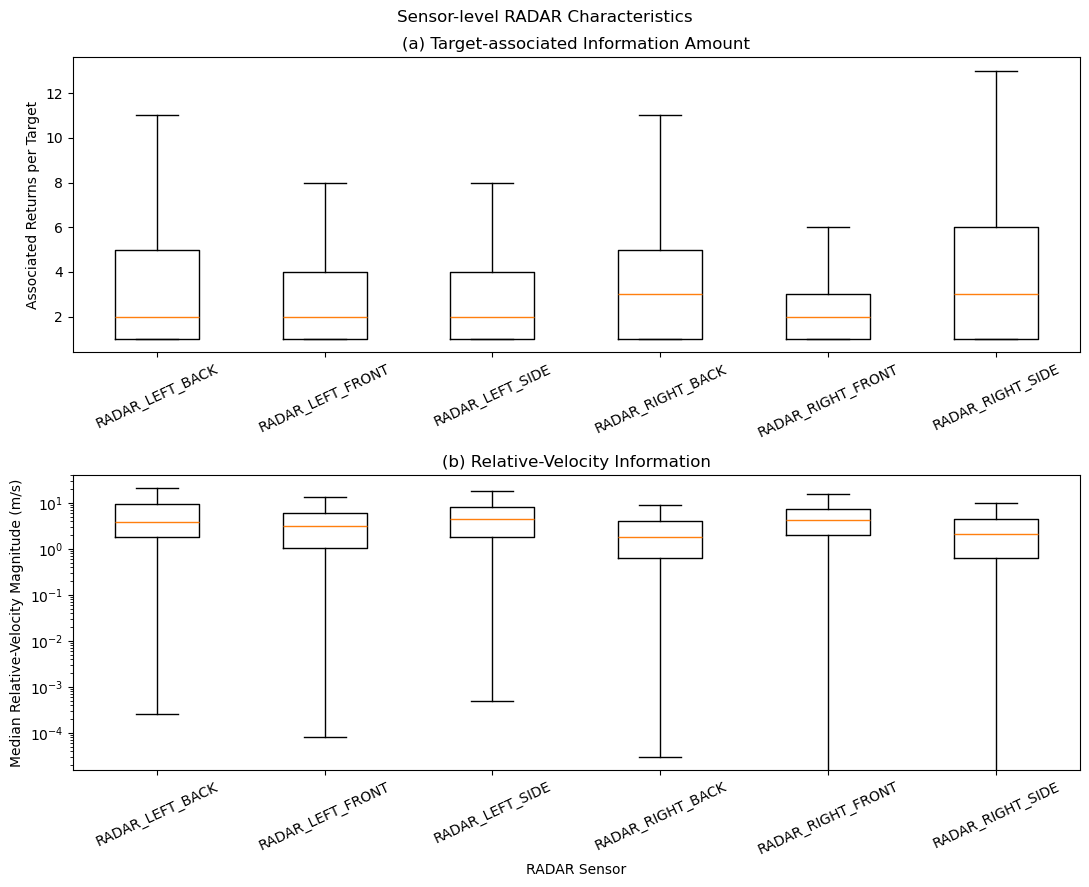

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9))

return_data = [radar_sensor_target_df.loc[radar_sensor_target_df["sensor"] == sensor, "radar_return_count"] for sensor in radar_sensors]
axes[0].boxplot(return_data, labels=radar_sensors, showfliers=False)
axes[0].set_ylabel("Associated Returns per Target")
axes[0].set_title("(a) Target-associated Information Amount")
axes[0].tick_params(axis="x", rotation=25)

velocity_data = [radar_sensor_target_df.loc[radar_sensor_target_df["sensor"] == sensor, "median_vrel_magnitude"] for sensor in radar_sensors]
axes[1].boxplot(velocity_data, labels=radar_sensors, showfliers=False)
axes[1].set_yscale("log")
axes[1].set_xlabel("RADAR Sensor")
axes[1].set_ylabel("Median Relative-Velocity Magnitude (m/s)")
axes[1].set_title("(b) Relative-Velocity Information")
axes[1].tick_params(axis="x", rotation=25)

fig.suptitle("Sensor-level RADAR Characteristics")
plt.tight_layout()
plt.show()

The six RADAR channels show differences in both target-associated information amount and relative-velocity characteristics. Most sensors provide a median of approximately two returns per target, while `RADAR_RIGHT_BACK` and `RADAR_RIGHT_SIDE` show slightly higher typical return counts. Relative-velocity distributions also differ between sensor channels. These variations should not be interpreted directly as differences in sensor quality because sensor orientation, field of view, target position, and line-of-sight geometry also affect the observed information.

### 4.4 RADAR Information across Comparable Reference-Speed Ranges

The annotation-derived 2D speed established in Section 3 is used to divide vehicle observations into comparable reference-speed ranges.

Each target-level RADAR observation is linked to the annotation-derived velocity interval beginning at the same annotation. This allows RADAR information acquisition and velocity-related measurements to be examined under comparable vehicle-motion conditions without treating vehicle speed as the direct cause of the observed differences.

In [40]:
radar_reference_df = target_radar_df.merge(
    vehicle_reference_df[["start_annotation_token", "speed_2d_mps"]],
    left_on="annotation_token",
    right_on="start_annotation_token",
    how="left",
    validate="one_to_one"
)

matched_radar_df = radar_reference_df.dropna(subset=["speed_2d_mps"]).copy()

print("RADAR target observations:", len(target_radar_df))
print("Matched reference intervals:", len(matched_radar_df))
print("Reference match rate (%):", round(len(matched_radar_df) / len(target_radar_df) * 100, 2))

RADAR target observations: 9588
Matched reference intervals: 9280
Reference match rate (%): 96.79


Of the 9,588 target-level RADAR observations, 9,280 (96.79%) can be linked to an annotation-derived reference-velocity interval. The remaining 308 observations correspond to the final annotation of an object trajectory, where no subsequent annotation is available to define a reference-velocity interval.

In [41]:
speed_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, np.inf]
speed_labels = ["0–<10", "10–<20", "20–<30", "30–<40", "40–<50", "50–<60", "60–<70", "70–<80", "80–<90", "90–<100", "100–<110", "≥110"]

reference_speed_df = vehicle_reference_df.copy()
reference_speed_df["speed_2d_kmh"] = reference_speed_df["speed_2d_mps"] * 3.6
reference_speed_df["speed_range_kmh"] = pd.cut(reference_speed_df["speed_2d_kmh"], bins=speed_bins, labels=speed_labels, right=False, include_lowest=True)

radar_speed_df = matched_radar_df.copy()
radar_speed_df["speed_2d_kmh"] = radar_speed_df["speed_2d_mps"] * 3.6
radar_speed_df["speed_range_kmh"] = pd.cut(radar_speed_df["speed_2d_kmh"], bins=speed_bins, labels=speed_labels, right=False, include_lowest=True)

In [42]:
reference_counts = reference_speed_df.groupby("speed_range_kmh", observed=False).size().rename("Reference Intervals")
radar_counts = radar_speed_df.groupby("speed_range_kmh", observed=False).size().rename("RADAR Observations")

radar_speed_summary = radar_speed_df.groupby("speed_range_kmh", observed=False).agg(
    Median_Returns=("radar_return_count", "median"),
    Median_Sensors=("radar_sensor_count", "median"),
    Median_Vrel=("median_vrel_magnitude", "median")
)

radar_speed_summary = pd.concat([reference_counts, radar_counts, radar_speed_summary], axis=1)
radar_speed_summary["RADAR Availability (%)"] = radar_speed_summary["RADAR Observations"] / radar_speed_summary["Reference Intervals"] * 100

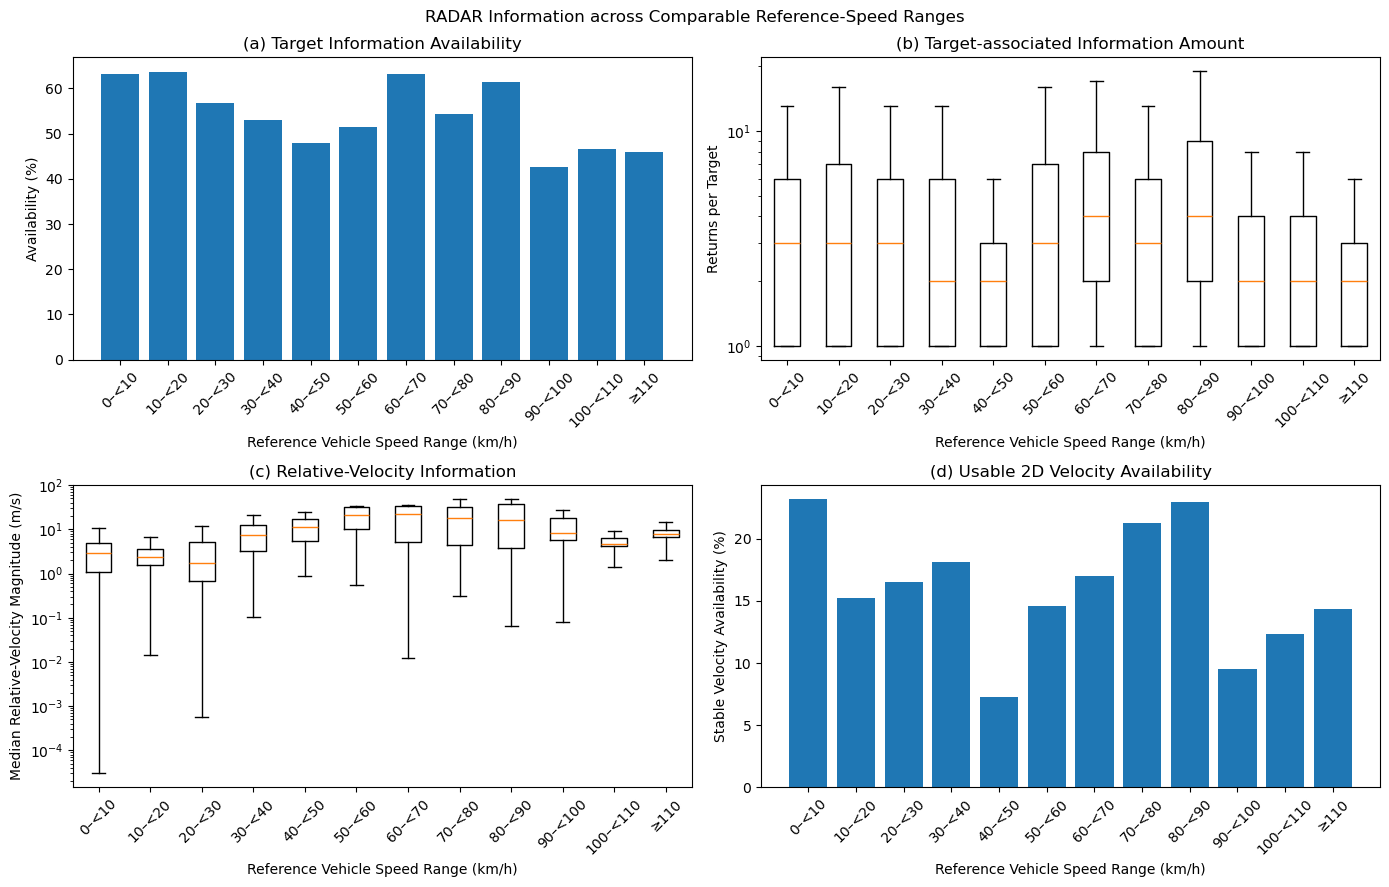

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
speed_categories = radar_speed_df["speed_range_kmh"].cat.categories
x_labels = [str(x) for x in speed_categories]

plot_data = radar_speed_summary.reset_index()

axes[0, 0].bar(x_labels, plot_data["RADAR Availability (%)"])
axes[0, 0].set_ylabel("Availability (%)")
axes[0, 0].set_title("(a) Target Information Availability")

return_data = [radar_speed_df.loc[radar_speed_df["speed_range_kmh"] == speed_range, "radar_return_count"].dropna() for speed_range in speed_categories]
axes[0, 1].boxplot(return_data, labels=x_labels, showfliers=False)
axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel("Returns per Target")
axes[0, 1].set_title("(b) Target-associated Information Amount")

velocity_data = [radar_speed_df.loc[radar_speed_df["speed_range_kmh"] == speed_range, "median_vrel_magnitude"].dropna() for speed_range in speed_categories]
axes[1, 0].boxplot(velocity_data, labels=x_labels, showfliers=False)
axes[1, 0].set_yscale("log")
axes[1, 0].set_ylabel("Median Relative-Velocity Magnitude (m/s)")
axes[1, 0].set_title("(c) Relative-Velocity Information")

stable_plot = stable_speed_summary.reset_index()
axes[1, 1].bar(x_labels, stable_plot["Stable Availability (%)"])
axes[1, 1].set_ylabel("Stable Velocity Availability (%)")
axes[1, 1].set_title("(d) Usable 2D Velocity Availability")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Reference Vehicle Speed Range (km/h)")

fig.suptitle("RADAR Information across Comparable Reference-Speed Ranges")
plt.tight_layout()
plt.show()

Across the comparable reference-speed ranges, RADAR target-information availability varies from approximately 43% to 64%, while the typical amount of associated information remains relatively small at approximately two to four returns per detected target. Neither measure follows a monotonic pattern across the speed conditions, indicating that the observed information acquisition cannot be explained by reference speed alone.

The direct relative-velocity information also varies substantially across the speed ranges and does not correspond one-to-one with annotation-derived absolute speed, consistent with the relative and line-of-sight nature of RADAR measurements. Stable 2D velocity availability ranges from approximately 7% to 23%, showing that the presence of target-associated returns does not necessarily provide sufficient geometric information for a stable Cartesian velocity reconstruction.

### 4.5 Usability of RADAR Velocity Information

The direct `vrel_*` measurements provide relative radial-motion information rather than a complete Cartesian target-velocity vector. A secondary reconstruction analysis is therefore used to examine whether the available RADAR information is sufficient to produce a usable 2D target-velocity estimate.

The validated workflow applies linear ego-motion compensation using `ego_motion_cabin`, combines radial-velocity constraints from both endpoints of each annotation interval, and reconstructs 2D ground-plane velocity using Huber robust least squares.

Numerical stability is evaluated using the condition number of the 2D line-of-sight system. The project baseline retains estimates with a condition number not exceeding 20.

The reconstructed velocity is used to evaluate the usability of the available RADAR velocity information. The annotation-derived 2D velocity remains the common reference vehicle-motion metric.

In [48]:
RADAR_CONDITION_LIMIT = 20

radar_radial_df = build_radar_radial_df(target_radar_points_df)
radar_velocity_df = build_radar_velocity_df(radar_radial_df, vehicle_reference_df, condition_limit=RADAR_CONDITION_LIMIT)

radar_stable_velocity_df = radar_velocity_df[radar_velocity_df["is_stable_2d"]].merge(
    vehicle_reference_df[["start_annotation_token", "end_annotation_token", "speed_2d_mps"]],
    on=["start_annotation_token", "end_annotation_token"],
    how="inner"
).copy()

radar_stable_velocity_df["radar_speed_2d_abs_error_mps"] = (radar_stable_velocity_df["radar_speed_2d_mps"] - radar_stable_velocity_df["speed_2d_mps"]).abs()

In [49]:
radar_velocity_summary = pd.DataFrame({
    "Metric": ["Reference intervals", "Full-rank RADAR velocity intervals", "Stable RADAR velocity intervals", "Raw velocity availability (%)", "Stable velocity availability (%)", "Median absolute speed error (m/s)", "75th percentile absolute error (m/s)"],
    "Value": [
        len(vehicle_reference_df),
        len(radar_velocity_df),
        len(radar_stable_velocity_df),
        len(radar_velocity_df) / len(vehicle_reference_df) * 100,
        len(radar_stable_velocity_df) / len(vehicle_reference_df) * 100,
        radar_stable_velocity_df["radar_speed_2d_abs_error_mps"].median(),
        radar_stable_velocity_df["radar_speed_2d_abs_error_mps"].quantile(0.75)
    ]
})

display(radar_velocity_summary.round(3))

,Metric,Value
0,Reference intervals,15743.000
1,Full-rank RADAR velocity intervals,7706.000
2,Stable RADAR velocity intervals,3016.000
3,Raw velocity availability (%),48.949
4,Stable velocity availability (%),19.158
5,Median absolute speed error (m/s),0.277
6,75th percentile absolute error (m/s),1.208


Of the 15,743 reference vehicle intervals, 7,706 contain sufficient RADAR constraints for a full-rank 2D reconstruction. After applying the condition-number threshold of 20, 3,016 intervals remain numerically stable, corresponding to 19.16% of the reference intervals.

For these stable estimates, the median absolute speed difference from the annotation-derived reference is approximately 0.277 m/s, while the 75th percentile is approximately 1.21 m/s. The substantially larger mean and maximum errors observed in the original distribution indicate a long error tail, so robust summary statistics are used for interpretation.

In [50]:
radar_stable_velocity_df["speed_2d_kmh"] = radar_stable_velocity_df["speed_2d_mps"] * 3.6
radar_stable_velocity_df["speed_range_kmh"] = pd.cut(radar_stable_velocity_df["speed_2d_kmh"], bins=speed_bins, labels=speed_labels, right=False, include_lowest=True)

stable_speed_summary = radar_stable_velocity_df.groupby("speed_range_kmh", observed=False).agg(
    Stable_Intervals=("radar_speed_2d_mps", "size"),
    Median_Abs_Error=("radar_speed_2d_abs_error_mps", "median"),
    P75_Abs_Error=("radar_speed_2d_abs_error_mps", lambda x: x.quantile(0.75))
)

stable_speed_summary = pd.concat([reference_counts, stable_speed_summary], axis=1)
stable_speed_summary["Stable Availability (%)"] = stable_speed_summary["Stable_Intervals"] / stable_speed_summary["Reference Intervals"] * 100

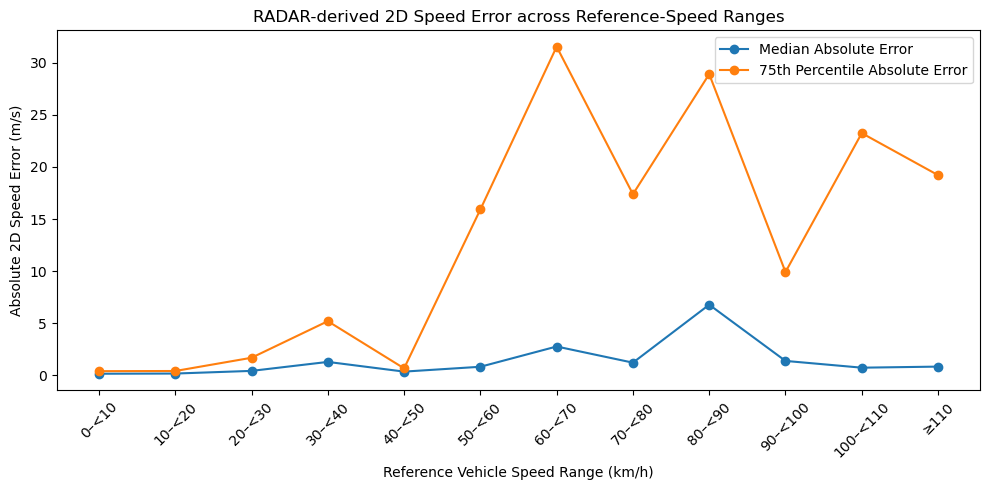

In [61]:
plot_data = stable_speed_summary.reset_index()
x = np.arange(len(plot_data))

plt.figure(figsize=(10, 5))
plt.plot(x, plot_data["Median_Abs_Error"], marker="o", label="Median Absolute Error")
plt.plot(x, plot_data["P75_Abs_Error"], marker="o", label="75th Percentile Absolute Error")
plt.xticks(x, plot_data["speed_range_kmh"].astype(str), rotation=45)
plt.xlabel("Reference Vehicle Speed Range (km/h)")
plt.ylabel("Absolute 2D Speed Error (m/s)")
plt.title("RADAR-derived 2D Speed Error across Reference-Speed Ranges")
plt.legend()
plt.tight_layout()
plt.show()

The agreement between stable RADAR-derived estimates and the annotation reference varies substantially across the reference-speed conditions. Median errors remain relatively small in several ranges, while the upper part of the error distribution becomes much wider in some medium- and high-speed ranges.

These differences should not be interpreted as a direct effect of vehicle speed. Reconstruction quality also depends on the available RADAR returns, line-of-sight geometry, and numerical conditioning. In addition, the number of stable estimates is uneven across the reference-speed ranges. Several ranges contain fewer than 100 stable intervals, including 40–50 km/h, 50–60 km/h, 90–100 km/h, and 100–110 km/h, so percentile-based error statistics in these ranges should be interpreted with additional caution.

### 4.6 Summary

The RADAR analysis reveals a clear distinction between the availability of direct velocity information and the ability to obtain a robust target-level vehicle-velocity estimate. TruckScenes RADAR directly provides `vrel_x`, `vrel_y`, and `vrel_z`, giving RADAR an inherent source of relative-motion information. However, this information is sparse at the target level: the 9,588 associated vehicle observations contain a median of only three RADAR returns, with a typical target supported by one RADAR sensor.

Target-associated RADAR information is available for approximately 43–64% of the reference intervals across the comparable speed ranges, but only 3,016 of the 15,743 reference intervals (19.16%) provide sufficient and numerically stable information for 2D velocity reconstruction. This indicates that detecting a vehicle and obtaining direct RADAR velocity measurements do not necessarily provide enough geometric information to recover a stable Cartesian target velocity.

When stable reconstruction is possible, the typical performance is strong, with a median absolute speed difference of only 0.277 m/s from the annotation-derived reference. However, the error distribution contains a substantial upper tail, showing that numerical stability alone does not guarantee an accurate estimate.

Overall, the main limitation of RADAR in this dataset is therefore not the absence of velocity information, but the consistency and geometric sufficiency of the target-associated measurements. The results across reference-speed ranges show no simple monotonic pattern, suggesting that RADAR information usability is influenced more strongly by factors such as return availability, sensor coverage, and line-of-sight geometry than by absolute vehicle speed alone.